In [5]:
%matplotlib widget
import matplotlib.pyplot as plt
import scipp as sc
from trex.instrument import Instrument
import scipp.constants as const
from scippneutron.tof import chopper_cascade

T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(2.5, unit="Å")
rrm: int = 8  # repetition rate multiplication factor
mode = "High Flux"  # Chopper mode


trex = Instrument(wavelength=central_wavelength, rrm=rrm, mode=mode, t_offset=T_OFFSET)
res = trex.model.run()

# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["Monitor at Sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]

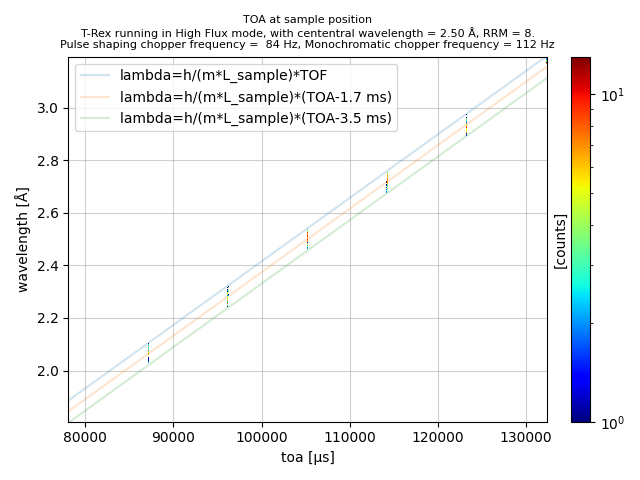

In [6]:
fig, ax = plt.subplots()
# tof_sample = events_at_sample.hist(wavelength=200, tof=500).plot(norm='log', ax=ax)
toa_sample = events_at_sample.hist(wavelength=800, toa=1500).plot(
    norm="log", cbar=True, ax=ax, cmap="jet"
)
ax.set_title("TOA at sample position\n" + str(trex), fontsize=8)
# TOF line
line_tof = sc.linspace("tof", 70, 140, 100, unit="ms").to(unit="us")
line_wavelength_tof = (
    const.h / const.m_n / trex.monitors["Monitor at Sample"].distance * line_tof
).to(unit="Å")
ax.plot(line_tof, line_wavelength_tof, label="lambda=h/(m*L_sample)*TOF", alpha=0.2)

# # TOA line
line_toa = sc.linspace("toa", 70, 140, 100, unit="ms").to(unit="us")
line_wavelength_toa = (
    const.h
    / const.m_n
    / trex.monitors["Monitor at Sample"].distance
    * (line_toa - T_OFFSET.to(unit="us"))
).to(unit="Å")
ax.plot(
    line_toa, line_wavelength_toa, label="lambda=h/(m*L_sample)*(TOA-1.7 ms)", alpha=0.2
)

line_wavelength_toa = (
    const.h
    / const.m_n
    / trex.monitors["Monitor at Sample"].distance
    * (line_toa - sc.scalar(3.5, unit="ms").to(unit="us"))
).to(unit="Å")
ax.plot(
    line_toa, line_wavelength_toa, label="lambda=h/(m*L_sample)*(TOA-3.5 ms)", alpha=0.2
)

ax.legend()
ax.grid(alpha=0.6)
fig.tight_layout()

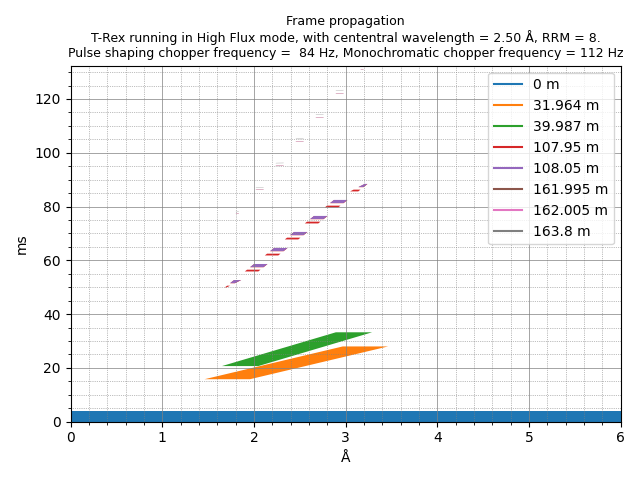

In [7]:
frames = chopper_cascade.FrameSequence.from_source_pulse(
    time_min=sc.scalar(0.0, unit="ms"),
    time_max=sc.scalar(4.0, unit="ms"),  # ESS pulse is 3 ms, but it has a tail
    wavelength_min=sc.scalar(0.0, unit="angstrom"),
    wavelength_max=sc.scalar(6.0, unit="angstrom"),
)
frames = frames.chop(trex.chopper_cascade.values())
at_sample = frames.propagate_to(trex.monitors["Monitor at Sample"].distance)

fig, ax = at_sample.draw(transpose=True)
ax.set_title("Frame propagation\n" + str(trex), fontsize=9)
ax.legend()
fig.tight_layout()

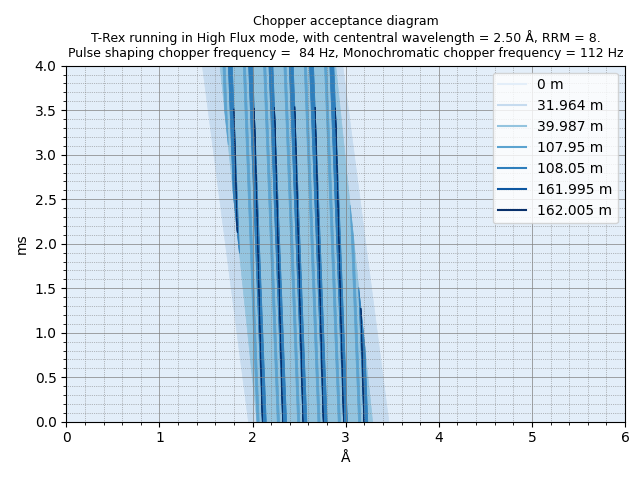

In [8]:
fig, ax = frames.acceptance_diagram()
ax.set_title("Chopper acceptance diagram\n" + str(trex), fontsize=9)
ax.legend()
fig.tight_layout()